In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.shape

(1025, 14)

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [8]:
target_column = 'target' 
print(df[target_column].value_counts())
print(df[target_column].value_counts(normalize=True))

target
1    526
0    499
Name: count, dtype: int64
target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


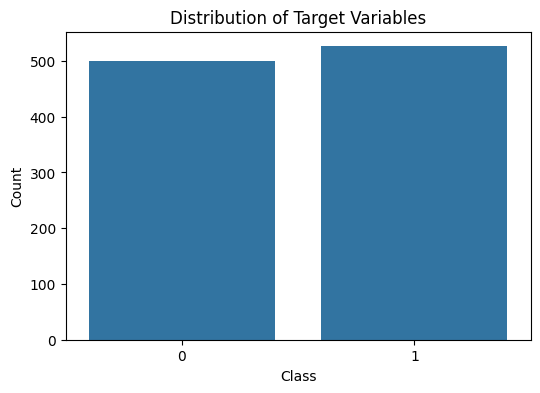

In [9]:
target_counts = df['target'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('Distribution of Target Variables')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

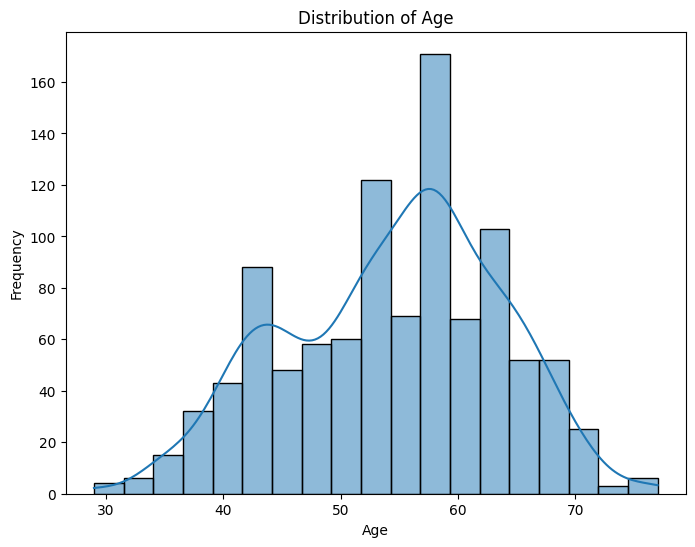

In [10]:
plt.figure(figsize=(8,6))
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

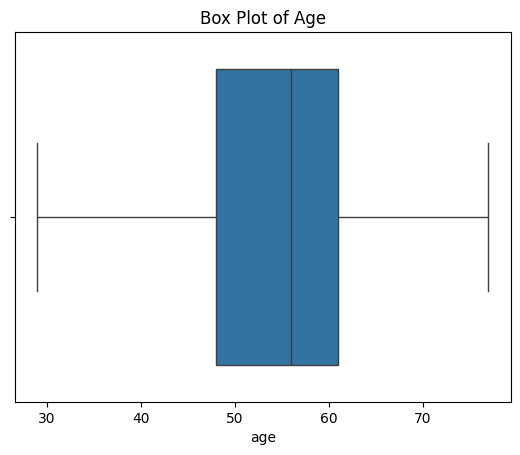

In [11]:
sns.boxplot(x=df['age'])
plt.title('Box Plot of Age')
plt.show()

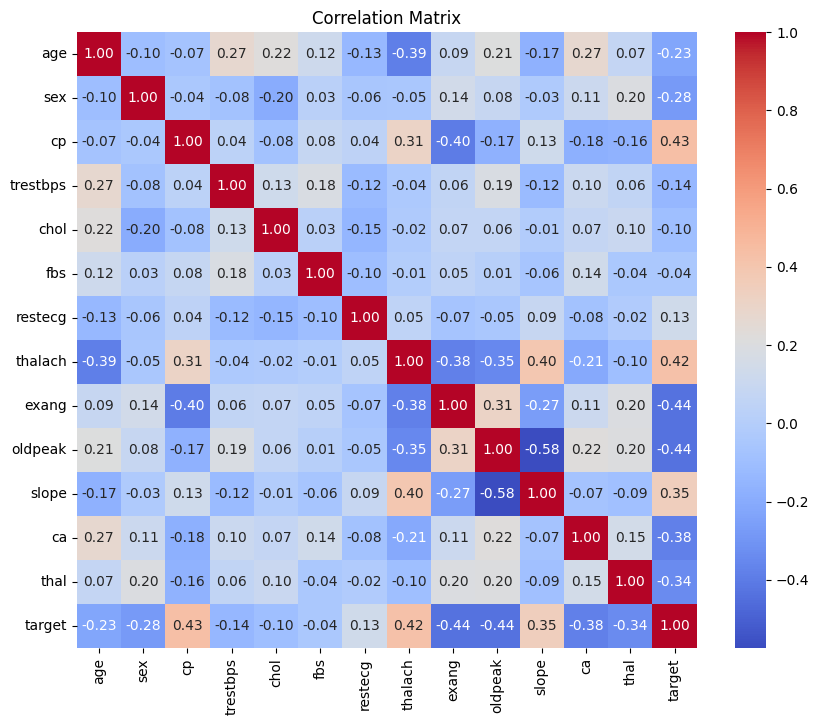

In [12]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

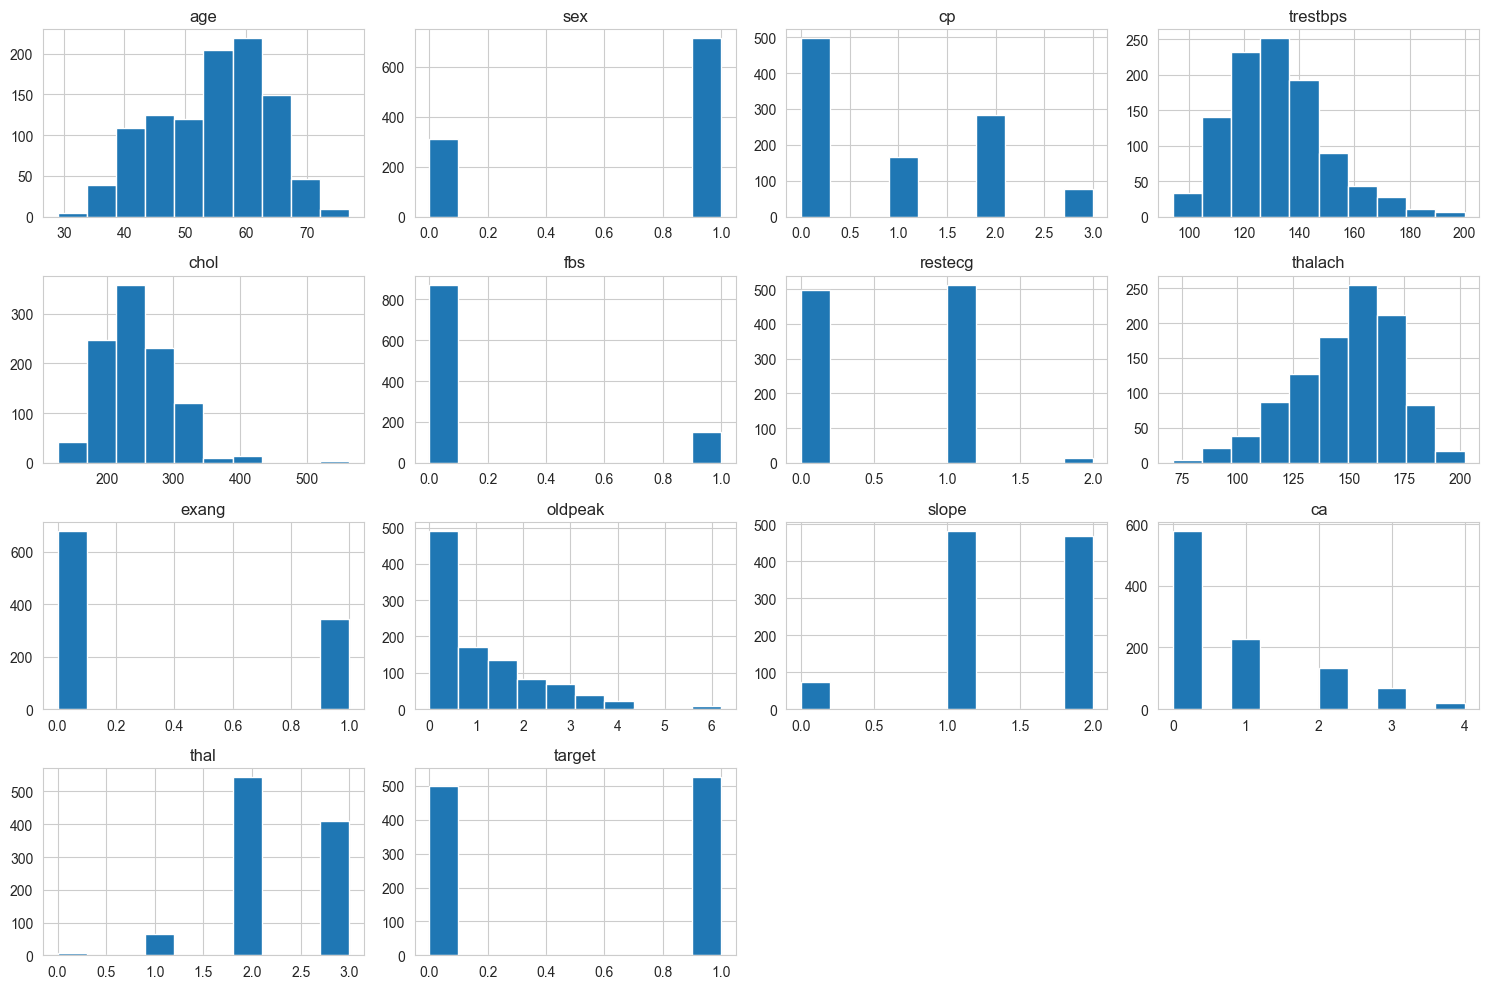

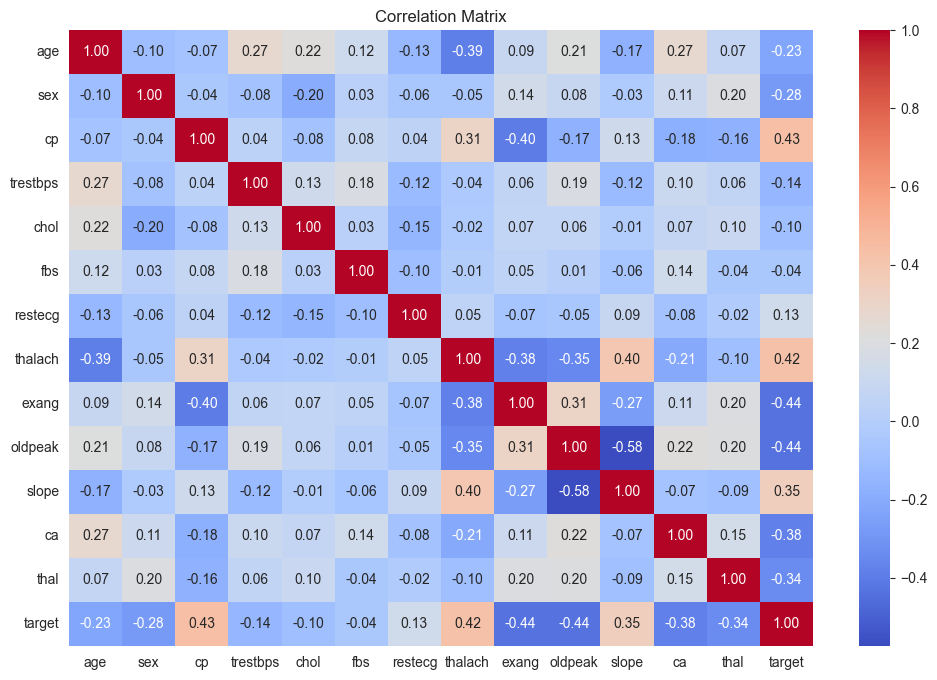

In [13]:
sns.set_style('whitegrid')
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [14]:
df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [15]:
def data_quality_report(df):
    report = pd.DataFrame(df.dtypes, columns=['Data Type'])
    report['Missing Values'] = df.isnull().sum()
    report['Unique Values'] = df.nunique()
    report['Min Value'] = df.min(numeric_only=True)
    report['Max Value'] = df.max(numeric_only=True)
    return report

print(data_quality_report(df))

         Data Type  Missing Values  Unique Values  Min Value  Max Value
age          int64               0             41       29.0       77.0
sex          int64               0              2        0.0        1.0
cp           int64               0              4        0.0        3.0
trestbps     int64               0             49       94.0      200.0
chol         int64               0            152      126.0      564.0
fbs          int64               0              2        0.0        1.0
restecg      int64               0              3        0.0        2.0
thalach      int64               0             91       71.0      202.0
exang        int64               0              2        0.0        1.0
oldpeak    float64               0             40        0.0        6.2
slope        int64               0              3        0.0        2.0
ca           int64               0              5        0.0        4.0
thal         int64               0              4        0.0    

In [16]:
df.replace('?', np.nan, inplace=True)
print("Missing values before handling:\n")
print(df.isnull().sum())
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print("\nMissing values after handling:\n")
print(df.isnull().sum())
import os
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/heart_cleaned.csv", index=False)
print("\n✅ Cleaned dataset saved to data/processed/heart_cleaned.csv")

Missing values before handling:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing values after handling:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

✅ Cleaned dataset saved to data/processed/heart_cleaned.csv


In [17]:
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for column in numerical_cols:
    if column in ['target', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']:  
        continue  # skip categorical columns

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # count before removing
    outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    print(f"Column '{column}': {outliers_count} outliers detected")

    # remove the outliers
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

Column 'age': 0 outliers detected
Column 'trestbps': 30 outliers detected
Column 'chol': 16 outliers detected
Column 'thalach': 4 outliers detected
Column 'oldpeak': 11 outliers detected


In [18]:
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# First pass: remove outliers
for column in numerical_cols:
    if column in ['target', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']:  
        continue  # skip categorical columns

    while True:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
        if outliers_count == 0:
            break  # stop if no more outliers
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [19]:
for column in numerical_cols:
    if column in ['target', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']:  
        continue
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    print(f"Column '{column}': {outliers_count} outliers detected")

Column 'age': 0 outliers detected
Column 'trestbps': 0 outliers detected
Column 'chol': 0 outliers detected
Column 'thalach': 0 outliers detected
Column 'oldpeak': 0 outliers detected


# Day 04

In [20]:
import cv2
print(cv2.__version__)

4.12.0


In [21]:
from PIL import Image
print("Pillow is working!")

Pillow is working!


In [22]:
import pytesseract
from PIL import Image
import re

print("All imports work!")

All imports work!


In [23]:
import os 
os.getcwd


<function nt.getcwd()>

✅ Image loaded successfully


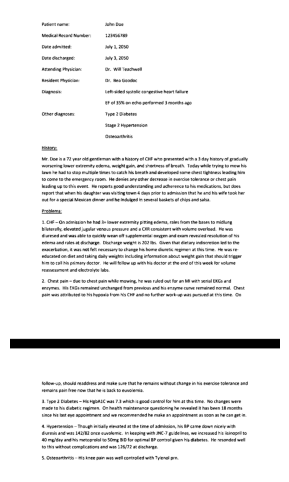


📜 Extracted Text:

Patient name: John Doe

Medical Record Number: 123456789

Date admitted: July 1, 2050

Date discharged: July 3, 2050

Attending Physician: Dr. Will Teachwell

Resident Physician: Dr. Bea Goodoc

Diagnosis: Left-sided systolic congestive heart failure

EF of 35% on echo performed 3 months ago
Other diagnoses: Tyne 2 Diabetes

Stage 2 Hypertension

Osteoarthritis

istory

Mr. Doe is a 72 year old gentleman with a history of CHF who presented with a 3 day history of gradually
worsening lower extremity edema, weight gain, and shortness of breath. Today while trying to mow his
lawn he had to stop multiple times to catch his breath and developed some chest tightness leading him
to come to the emergency raom. He denies any other decrease in exercise telerance ar chest pain
leading up to this event. He reports good understanding and adherence to his medications, but does
report that when his daughter was visiting town 4 days prior to admission that he and his wife took her


In [24]:
import cv2
from PIL import Image
import pytesseract
from matplotlib import pyplot as plt

# 1️⃣ Set the path to your image
image_path = r"C:\Users\abhii\OneDrive\Pictures\sample_image.png"

# 2️⃣ Load image with OpenCV
image = cv2.imread(image_path)

# 3️⃣ Check if image is loaded
if image is None:
    print("❌ Image not found. Check the path!")
else:
    print("✅ Image loaded successfully")

    # 4️⃣ Preprocess image (grayscale + thresholding)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]

    # 5️⃣ Optional: show processed image
    plt.figure(figsize=(8,6))
    plt.imshow(thresh, cmap='gray')
    plt.axis('off')
    plt.show()

    # 6️⃣ Extract text with pytesseract
    # If on Windows, make sure tesseract_cmd is set:
    # pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
    extracted_text = pytesseract.image_to_string(Image.fromarray(thresh))

    # 7️⃣ Print extracted text
    print("\n📜 Extracted Text:\n")
    print(extracted_text)

# Day 05

In [25]:
import pandas as pd

# Load dataset
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Standardization (mean=0, std=1)
scaler_std = StandardScaler()
df[num_cols] = scaler_std.fit_transform(df[num_cols])

# Normalization (optional: scales between 0 and 1)
scaler_minmax = MinMaxScaler()
df[num_cols] = scaler_minmax.fit_transform(df[num_cols])

In [27]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [28]:
# Example derived feature
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 80], labels=['Young', 'Adult', 'Senior', 'Elder'])

# Example risk score (dummy)
df['risk_score'] = df['chol'] * 0.3 + df['trestbps'] * 0.7

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols)
    ],
    remainder='passthrough'
)

# Example usage:
df_transformed = preprocessor.fit_transform(df)
df_transformed = pd.DataFrame(df_transformed, columns=df.columns)

In [30]:
from sklearn.preprocessing import LabelEncoder

if 'age_group' in df.columns:
    le = LabelEncoder()
    df['age_group'] = le.fit_transform(df['age_group'])

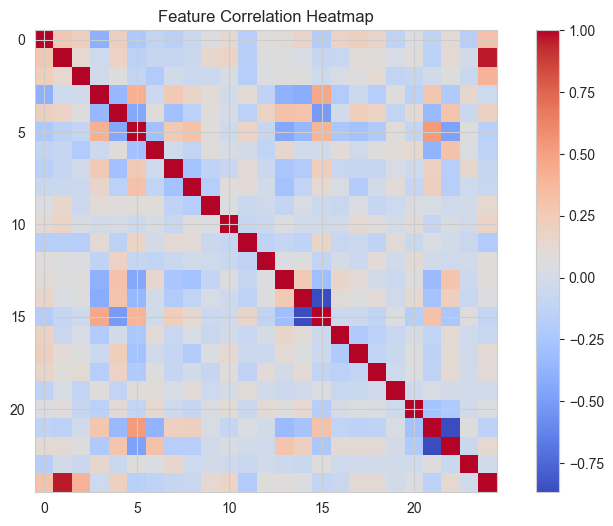

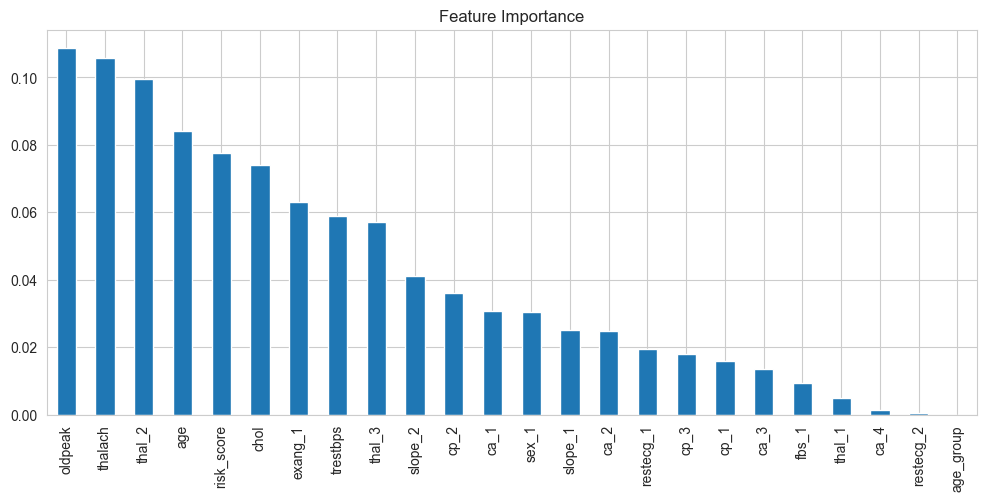

In [31]:
import matplotlib.pyplot as plt

# Correlation heatmap
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature Importance (example with RandomForest)
from sklearn.ensemble import RandomForestClassifier

X = df.drop('target', axis=1)
y = df['target']

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12, 5), title="Feature Importance")
plt.show()

In [32]:
from scipy.stats import ttest_ind

# Example t-test for age between two target classes
group1 = df[df['target'] == 0]['age']
group2 = df[df['target'] == 1]['age']
t_stat, p_val = ttest_ind(group1, group2)
print(f"T-statistic: {t_stat}, P-value: {p_val}")

T-statistic: 7.53559120796224, P-value: 1.0677220241597297e-13


# Day 06

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your cleaned and feature-engineered dataset
df = pd.read_csv("data/processed/heart_cleaned.csv")  # Use final dataset from Day 5

X = df.drop('target', axis=1)
y = df['target']

# First split: Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: Validation (15%) + Test (15%) from Temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("✅ Data Splits:")
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

✅ Data Splits:
Train: (717, 13), Validation: (154, 13), Test: (154, 13)


In [34]:
def check_distribution(y_train, y_val, y_test):
    print("\nClass Distribution Check:")
    for name, y in zip(["Train", "Validation", "Test"], [y_train, y_val, y_test]):
        print(f"{name}:")
        print(y.value_counts(normalize=True))
        print("-"*20)

check_distribution(y_train, y_val, y_test)


Class Distribution Check:
Train:
target
1    0.51325
0    0.48675
Name: proportion, dtype: float64
--------------------
Validation:
target
1    0.512987
0    0.487013
Name: proportion, dtype: float64
--------------------
Test:
target
1    0.512987
0    0.487013
Name: proportion, dtype: float64
--------------------


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split

def load_raw_data(path):
    return pd.read_csv(path)

def clean_data(df):
    # Example: drop duplicates & fill missing
    df = df.drop_duplicates()
    df = df.fillna(df.median(numeric_only=True))
    return df

def feature_engineer(df):
    # Example: create age groups
    df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 80], labels=['Young', 'Adult', 'Senior', 'Elder'])
    df = pd.get_dummies(df, columns=['age_group'], drop_first=True)
    return df

def split_data(df):
    X = df.drop('target', axis=1)
    y = df['target']
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

def run_pipeline():
    df = load_raw_data("heart.csv")
    df = clean_data(df)
    df = feature_engineer(df)
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)
    
    # Save outputs
    X_train.join(y_train).to_csv("data/processed/train.csv", index=False)
    X_val.join(y_val).to_csv("data/processed/val.csv", index=False)
    X_test.join(y_test).to_csv("data/processed/test.csv", index=False)
    
    return df

if __name__ == "__main__":
    final_df = run_pipeline()
    print("✅ Data pipeline completed. Final shape:", final_df.shape)

✅ Data pipeline completed. Final shape: (302, 17)


In [36]:
def clean_data(df):
    # Remove duplicate rows
    before = len(df)
    df = df.drop_duplicates()
    after = len(df)
    print(f"🧹 Removed {before - after} duplicate rows.")
    
    # Fill missing numeric values with median
    df = df.fillna(df.median(numeric_only=True))
    return df

In [44]:
def validate_data(df):
    print("✅ Data Validation Report")
    print("Number of rows:", len(df))
    print("Missing values:\n", df.isnull().sum())
    print("Duplicate rows:", df.duplicated().sum())
    print("Data types:\n", df.dtypes)
    return True

In [45]:
df = clean_data(df)
validate_data(df)

🧹 Removed 723 duplicate rows.
✅ Data Validation Report
Number of rows: 302
Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Duplicate rows: 0
Data types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


True

In [40]:
# Generate descriptive statistics
summary = df.describe(include='all')

# Save to reports folder
import os
os.makedirs("reports", exist_ok=True)
summary.to_csv("reports/final_dataset_summary.csv")

print("✅ Final dataset summary saved to reports/final_dataset_summary.csv")

✅ Final dataset summary saved to reports/final_dataset_summary.csv


In [41]:
class_dist = df['target'].value_counts(normalize=True) * 100
class_dist.to_csv("reports/class_distribution.csv")
print("✅ Class distribution report saved.")
print(class_dist)

✅ Class distribution report saved.
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


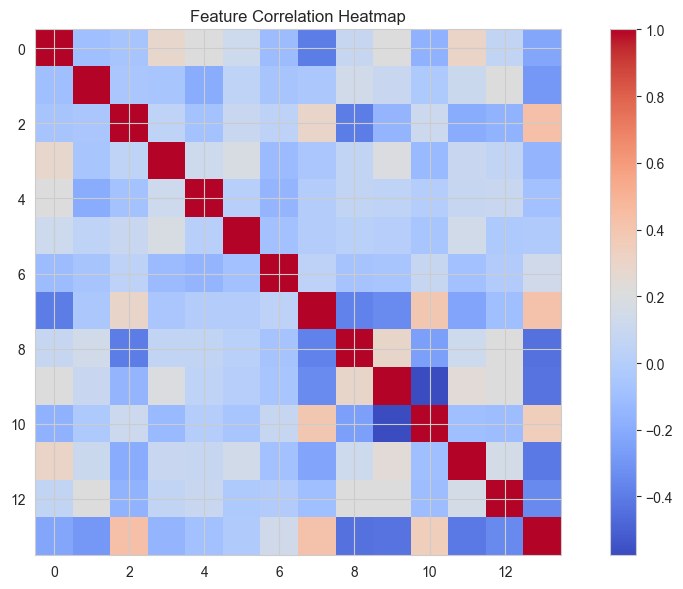

✅ Correlation heatmap saved in reports/


In [42]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

plt.figure(figsize=(10, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("reports/correlation_heatmap.png")
plt.show()

print("✅ Correlation heatmap saved in reports/")

# Milestone - 02

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

df = pd.read_csv('heart.csv') 

# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7951219512195122
Confusion Matrix:
 [[73 29]
 [13 90]]


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

# Load dataset
df = pd.read_csv('heart.csv') 

# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for SVM and Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.9853658536585366
Confusion Matrix:
 [[102   0]
 [  3 100]]


In [58]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))

SVM Accuracy: 0.8878048780487805
Confusion Matrix:
 [[85 17]
 [ 6 97]]


In [54]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_model.fit(X_train_scaled, y_train)

mlp_pred = mlp_model.predict(X_test_scaled)
print("Neural Network Accuracy:", accuracy_score(y_test, mlp_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, mlp_pred))

Neural Network Accuracy: 0.9853658536585366
Confusion Matrix:
 [[102   0]
 [  3 100]]


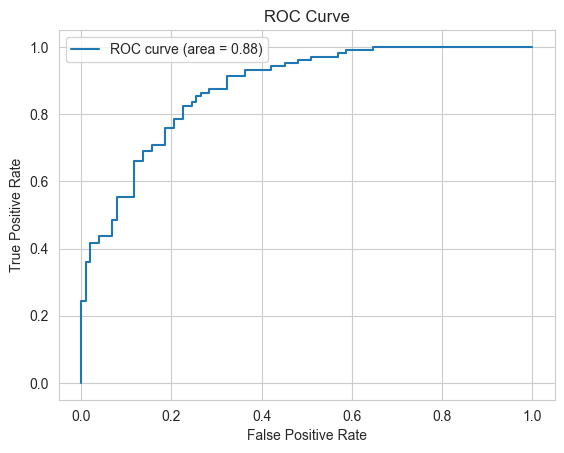

In [56]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [59]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
